In [1]:
# need to restart jupyter server? kernal? whenever a change is made to the pybamm module? 
import sys
import os
sys.path.insert(0,os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("__file__")))))
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
# sys.path.insert(1,r'C:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\venv\Lib\MiKTeX')
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
# os.chdir(sys.path[0] + '\..') # change our working directory to the root of the pybamm folder
import pybamm
print(pybamm.__path__[0])
from scipy import integrate, signal, constants
from pybamm import exp, constants, Parameter
# import matplotlib
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': 'Computer Modern',
    'font.sans-serif': ['Computer Modern'],
    'font.size': 11,
})
%matplotlib widget
# pybamm.set_logging_level("INFO")

# reset plt settings
# import matplotlib as mpl
# mpl.rcParams.update(mpl.rcParamsDefault)

c:\Users\Vivian\Dropbox (University of Michigan)\from_box\Research\PyBaMM\PyBaMM\pybamm


# Set up simulation

In [2]:
class ExternalCircuitResistanceFunction():
    def __call__(self, variables):
        I = variables["Current [A]"]
        V = variables["Terminal voltage [V]"]
        R_ext = pybamm.FunctionParameter("External short resistance [Ohm]",  {"Time [s]": pybamm.t}) 
        R_tab = pybamm.FunctionParameter("Tabbing resistance [Ohm]",  {"Time [s]": pybamm.t})
        return V/I - (R_ext + R_tab)

In [3]:
Q_nom = 4.6
t_end = 13*60

def load_data(SOC_0, SOC_name):
    # load data import ESC data from file
    raw_data = pd.read_csv("ESC_"+  SOC_name + "SOC_full.csv")
    esc_start = raw_data[-raw_data['Current Shunt']>1].index[0]-1
    esc_end = raw_data[raw_data['Time (s)']>(raw_data['Time (s)'].loc[esc_start]+t_end)].index[0]
    T_amb = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data = raw_data[['Time (s)', 'Voltage (V)', 'Cell Temperature', 'Current Shunt', 'Force']].loc[esc_start:esc_end].copy()
    data['Cell Temperature'][data['Cell Temperature']>140] = None
    data.interpolate(inplace=True)
    data['Current Shunt'] = -data['Current Shunt']
    data['Time (s)'] = data['Time (s)'] - data['Time (s)'].loc[esc_start]
    data['Force'] = (data['Force'] - data['Force'].loc[esc_start])*9.81
    df_labels = ['t', 'V', 'Temp','I', 'F']
    data.set_axis(df_labels, axis=1, inplace=True)
    data['I_C'] = data.I/Q_nom 
    AhT_calculated = integrate.cumtrapz(abs(data.I), data.t-data.t.iloc[0])/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    data['SOC'] = SOC_0 - AhT_calculated/Q_nom # load data import ESC data from file
    if SOC_name =='100B':
        data['V'][(data.t[0:-1]>800) & (data.V>0.1)]  = None # remove voltage recovery on 100B

    T_amb_0 = np.mean(raw_data['Cell Temperature'][(raw_data.index < esc_start) & (raw_data['Cell Temperature'] >0)])
    data.reset_index(drop=True, inplace=True)

    return data, T_amb_0

display(load_data(0.75, '75')[0])

C:\Users\Vivian\AppData\Local\Temp\ipykernel_4224\3556686945.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)


,t,V,Temp,I,F,I_C,SOC
0,0.000,3.907343,21.886238,0.832958,0.000000,0.181078,0.749301
1,0.100,1.447498,21.965434,230.630669,0.190512,50.137102,0.747918
2,0.200,1.408588,21.896138,227.542398,0.730296,49.465739,0.746547
3,0.300,1.388854,21.866438,226.594000,0.825552,49.259565,0.745182
4,0.400,1.379884,21.995131,225.494177,0.984312,49.020473,0.743822
...,...,...,...,...,...,...,...
7796,779.607,0.019675,70.322044,4.235999,-53.406875,0.920869,0.160801
7797,779.707,0.019675,70.322044,4.152318,-53.438627,0.902678,0.160776
7798,779.807,0.019635,70.302885,4.136378,-53.597387,0.899213,0.160750
7799,779.907,0.019595,70.312464,4.295771,-53.438627,0.933863,0.160725


In [4]:
def modified_graphite_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Negative electrode diffusion coefficient [m2.s-1]")
    # D_ref = 16*5.0 * 10 ** (-15)
    # E_D_s = 42770
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (sto - 0)/(0.8321-0)
    k = 1.12070451*soc + 0.09209274 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate) only exclude kn>9

    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.246491535,0.177990605,0.109487916][-1:0:-1])
    # k_fit = np.array([0.998960993,0.962562613,1.088848875,0.960830764,0.980577779,0.767837023,0.826562007,0.192714141,0.571586523,0.725658028][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref*k #*arrhenius # *(-0.9 * sto + 1)

def modified_NMC_diffusivity_PeymanMPM(sto, T):
    D_ref =  Parameter("Positive electrode diffusion coefficient [m2.s-1]")
    # E_D_s = 18550
    # arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    soc = (0.837-sto)/(0.837-0.034)
    k =  4.7302281*soc**2  -4.5023245*soc + 1.26466141 # Ds_restart_rmseV_11_simultaneous_rest (updated exp C-rate)
    # soc_fit = np.array([0.931499472,0.862995346,0.79449311,0.725995244,0.657493658,0.588993969,0.520494998,0.451992894,0.383496394,0.31499461,0.246491535,0.109487916][-1:0:-1])
    # k_fit = np.array([1.224990159,0.918644845,0.646317414,0.418199795,0.250350793,0.318672366,0.267289649,0.182154457,0.11139899,0.329794626,0.337200374,0.418978523][-1:0:-1])
    # x = [soc]
    # k = pybamm.Interpolant(soc_fit, k_fit, x, name=None, interpolator='linear', extrapolate=True, entries_string=None)
    
    return D_ref *k #*arrhenius

def modified_electrolyte_diffusivity_PeymanMPM(c_e, T):
    # D_c_e = 5.35 * 10 ** (-10)
    D_c_e =  Parameter("Typical electrolyte diffusivity [m2.s-1]")
    return D_c_e

def modified_electrolyte_conductivity_PeymanMPM(c_e, T):
    # sigma_e = 1.3
    sigma_e = Parameter("Typical electrolyte conductivity [m2.s-1]")
    E_k_e = 34700
    return sigma_e


def modified_NMC_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4.824 * 10 ** (-6)  # (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 /T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #* arrhenius
    )

def modified_graphite_electrolyte_exchange_current_density_PeymanMPM(c_e, c_s_surf, c_s_max, T):
    m_ref =  Parameter("Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]")
    # m_ref = 4*1.061 * 10 ** (-6)  # unit has been converted units are (A/m2)(mol/m3)**1.5 - includes ref concentrations
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))

    return (
        m_ref * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5 #*arrhenius
    )


In [5]:
Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
# Cps = {'100A': 1.27306111, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845}
# hs = {'100A':16.6726177, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175}
R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007}
R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067}
k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}

Cps.update({'avg': np.mean([Cps[k] for k in Cps.keys()])})
hs.update({'avg': np.mean([hs[k] for k in hs.keys()])})
R_tabs.update({'avg': np.mean([R_tabs[k] for k in R_tabs.keys()])})
# R_tabs.update({'avg': 0})
R_escs.update({'avg': np.mean([R_escs[k] for k in R_escs.keys()])})
k_A_sei.update({'avg': np.mean([k_A_sei[k] for k in k_A_sei.keys()])})

In [6]:
param_update_iso = {        
    "Negative electrode diffusivity [m2.s-1]": modified_graphite_diffusivity_PeymanMPM,
    "Positive electrode diffusivity [m2.s-1]": modified_NMC_diffusivity_PeymanMPM,
    "Electrolyte diffusivity [m2.s-1]": modified_electrolyte_diffusivity_PeymanMPM,
    "Electrolyte conductivity [S.m-1]": modified_electrolyte_conductivity_PeymanMPM,
    # "Initial concentration in electrolyte [mol.m-3]":1000, #*1.3
    "Negative electrode exchange-current density [A.m-2]": modified_graphite_electrolyte_exchange_current_density_PeymanMPM,
    "Positive electrode exchange-current density [A.m-2]": modified_NMC_electrolyte_exchange_current_density_PeymanMPM,
    "Negative electrode OCP entropic change [V.K-1]":0,
    "Positive electrode OCP entropic change [V.K-1]":0,
    }

In [7]:
def sim_ESC(SOC_0, SOC_name, param_update = {}, SOC_param = "", k_h_sei = 1):    # need to "data,T_amb_0 = load_data(SOC_0, SOC_name)" before running
    data, T_amb = load_data(SOC_0, SOC_name)
    R_tab = pybamm.Parameter("Tabbing resistance [Ohm]")
    # R_ext = pybamm.Parameter("External short resistance [Ohm]")

    Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
    hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
    # Cps = {'100A': 1.27306111, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845}
    # hs = {'100A':16.6726177, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175}
    R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007-0.0007}
    R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067+0.0007}
    k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}

    # calc avg value
    Cps.update({
        'avg': np.mean([Cps[k] for k in Cps.keys()]),
        # 'avg vent': np.mean([Cps['100A'],Cps['100B'] ]),
        # 'avg no vent': np.mean([Cps['75'],Cps['50'] ]),
        })
    hs.update({
        'avg': np.mean([hs[k] for k in hs.keys()]),
        # 'avg vent': np.mean([hs[k] for k in hs.keys()]),
        # 'avg no vent': np.mean([hs[k] for k in hs.keys()]),
        })
    R_tabs.update({
        'avg': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        # 'avg':0,
        # 'avg vent': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        # 'avg no vent': np.mean([R_tabs[k] for k in R_tabs.keys()]),
        })
    R_escs.update({
        'avg': np.mean([R_escs[k] for k in R_escs.keys()]),
        # 'avg vent': np.mean([R_escs[k] for k in R_escs.keys()]),
        # 'avg no vent': np.mean([R_escs[k] for k in R_escs.keys()]),
        })
    k_A_sei.update({
        'avg': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        # 'avg vent': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        # 'avg no vent': np.mean([k_A_sei[k] for k in k_A_sei.keys()]),
        })

    if SOC_param =="":
        SOC_param = SOC_name
    option = {
        "thermal": "lumped",
        "decomposition": "true", 
        "operating mode": ExternalCircuitResistanceFunction(),
        "cell geometry": "arbitrary",
        "venting":"true",
        "heat of mixing": "true",
        # "loss of active material": "electrolyte dryout", 
    }

    model = pybamm.lithium_ion.SPMe(options = option)
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    
    param.update({
        "Frequency factor for SEI decomposition [s-1]": 2.25E15*k_A_sei[SOC_param],
        "Enthalpy of SEI decomposition [J.kg-1]":257000*k_h_sei,
        'Internal short resistance [Ohm]':1e16,
        "Tabbing resistance [Ohm]":  R_tabs[SOC_param],#0.0041,D
        "External short resistance [Ohm]": R_escs[SOC_param], # 0.0067
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
        "Lower voltage cut-off [V]": 0,
        "Ambient temperature [K]":T_amb + 273.15,
        "Initial temperature [K]": T_amb + 273.15,
        "Initial cell compression stress [kPa]": data['F'].iloc[0]/param['Active material surface area [m2]']/1000,
        "Total heat transfer coefficient [W.m-2.K-1]":hs[SOC_param],
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cps[SOC_param],
    }, check_already_exists = False)

    param.update(param_update, check_already_exists = False)
    
    V = model.variables["Terminal voltage [V]"]
    I = model.variables["Current [A]"]
    model.variables.update({
        "Terminal voltage [V]": V - I*R_tab,
        "Actual resistance [Ohm]":V/I,
        }
    )
    
    dt = 0.1
    t_eval = np.arange(0, t_end, dt) #16*60
    solver = pybamm.CasadiSolver(mode="safe", dt_max = 10) #, extra_options_setup={"max_num_steps": 10000}
    sim = pybamm.Simulation(model, parameter_values = param, solver=solver) 
    solution = sim.solve( initial_soc=SOC_0, t_eval = t_eval)
    return solution

solution = sim_ESC(1, '100A')


C:\Users\Vivian\AppData\Local\Temp\ipykernel_4224\3556686945.py:17: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(df_labels, axis=1, inplace=True)


In [8]:
# def ocv(soc): # from hppc rest
#     p0 = np.array([0.114319142120841,  -0.663997904709863, 
#             1.686768366470837,  -2.462409468590447,   2.282769243949050, 
#             -1.401600551327618,   0.576551904459066,  -0.157044814050174, 
#             0.027351974716897,  -0.002866912229499,   0.000171009483610,
#             0.000029999998915])*1e5
#     return np.polyval(p0,soc)

def ocv(soc): # from C/10
    p0 = np.array([0.018506268107831,  -0.136071028323453, 
            0.443060938604833,  -0.839776753517996,   1.024213621638298, 
            -0.839264034243947,   0.470188190051651,  -0.183011124631359, 
            0.053509361841394,  -0.015162911494282,   0.005025031383283,
            -0.001474328544519, 0.000287406587189, -0.000032455129489, 
            0.000001937547848,  0.000000299017470
        ])*1e7
    return np.polyval(p0,soc)

# Run SPMe simulation 

In [9]:
Cps = {'100A': 2.4847642158614396, '100B': 2.131841251256563, '75': 1.7615851440073333, '50': 1.8069119898506183}    # 12/31 test   T only, no weights
hs = {'100A': 34.83874617168782, '100B': 34.211742173359575, '75': 37.17732764082647, '50': 35.31863975361435}   
# Cps = {'100A': 1.27306111, '100B': 1.09465293, '75': 0.96645967, '50': 1.0120845}
# hs = {'100A':16.6726177, '100B': 17.81984063, '75': 19.81810618, '50': 20.00621175}
R_tabs = {'100A':  0.0086, '100B':0.0049, '75':0.0078+0.0005, '50':0.007-0.0007}
R_escs = {'100A':  0.0067, '100B':0.004, '75':0.0067-0.0005, '50':0.0067+0.0007}
k_A_sei = {'100A':  0.07912785, '100B':0.238155, '75':0.04571944, '50':0.05716926}

In [10]:
SOC_names = ['100A','100B', '75', '50'] 
# SOC_names = ['100B', '75', '50']
SOC_0s = {'100A': 1, '100B': 1, '75': 0.75, '50': 0.5}

datas = []
solutions_pybamm_model=[]

for SOC_name in SOC_names: 
    print(SOC_name)

    # load data and sim 
    SOC_0 = SOC_0s[SOC_name]
    data = load_data(SOC_0, SOC_name)[0]
    solution = sim_ESC(SOC_0, SOC_name, param_update = param_update_iso, SOC_param = SOC_name)
    solutions_pybamm_model.append(solution)
    
    datas.append(data)


100A
100B
75
50


# Check that fitting model runs

In [11]:
# chemistry = pybamm.parameter_sets.Tran2023
# param = pybamm.ParameterValues(chemistry)
# T_amb_0 = datas[0].Temp[0]

# param.update({
#     "Ambient temperature [K]":T_amb_0 + 273.15,
#     "Initial temperature [K]": T_amb_0 + 273.15,
#     "Negative tab width [m]":2.5e-2,
#     "Positive tab width [m]":2.5e-2,
#     # "Edge heat transfer coefficient [W.m-2.K-1]":h,
#     "Total heat transfer coefficient [W.m-2.K-1]":h,
#     "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
#     "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
#     "Cell open circuit voltage [V]": ocv,
#     "Cell capacity [A.h]": 4.6, #nominal
#     "Typical current [A]": 4.6,
#     "Negative electrode thickness [m]":62E-06*4.2/5,
#     "Positive electrode thickness [m]":67E-06*4.2/5,
# }, check_already_exists = False)
# liion = pybamm.LithiumIonParameters()
# param.evaluate(liion.tau_discharge)/3600 #  self.F * self.c_max * self.L_x / self.i_typ
# param.evaluate(liion.geo.A_cc)

In [48]:
#calculate cell mass m in mCp
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
liion = pybamm.LithiumIonParameters()

param.update({
    "Ambient temperature [K]":25 + 273.15,
    "Initial temperature [K]": 25 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    # "Edge heat transfer coefficient [W.m-2.K-1]":h,
    # "Total heat transfer coefficient [W.m-2.K-1]":h,
    # "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    # "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Cell open circuit voltage [V]": ocv,
    "Cell capacity [A.h]": 4.6, #nominal
    "Typical current [A]": 4.6,
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
# rho = param.evaluate(liion.rho_dim(273.15+25)) # [J.m-3.K-1] Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
# cell_volume = param.evaluate(liion.V_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
V_cell_norm = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) #includes cc

T = 273.15+25
mass = param.evaluate((
    liion.therm.n.rho_cc_dim(T) * liion.geo.n.L_cc
    + liion.therm.n.rho_dim(T) * liion.n.L
    + liion.therm.s.rho_dim(T) * liion.s.L
    + liion.therm.p.rho_dim(T) * liion.p.L
    + liion.therm.p.rho_cc_dim(T) * liion.p.L_cc
))*(param.evaluate(liion.L_y) *param.evaluate(liion.L_z))
mass


0.129602025

In [12]:
def sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I, dV):  
# def sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t,Q):  

    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        # "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)

    # Define input and output
    Q_vol_av = pybamm.Variable("Volume-averaged total heating")
    T_vol_av= pybamm.Variable("Volume-averaged cell temperature")

    # Init model and variables
    liion = pybamm.LithiumIonParameters()
    model = pybamm.BaseModel()
    Delta_T = param.evaluate(liion.Delta_T)
    T_ref = param.evaluate(liion.T_ref)
    tau_discharge = param.evaluate(liion.tau_discharge)
    tau_th_yz = param.evaluate(liion.tau_th_yz)
    model.timescale = pybamm.Scalar(tau_discharge)
    model.variables = {
        "Volume-averaged total heating": Q_vol_av, 
        "Volume-averaged cell temperature": T_vol_av,
        "Volume-averaged cell temperature [K]": Delta_T * T_vol_av + T_ref,
    }
    model.external_variables = [Q_vol_av]

    # Set up parameters
    # thermal = pybamm.thermal_parameters
    delta = param.evaluate(liion.delta) #self.L_x / self.L_z
    cell_surface_area = param.evaluate(liion.a_cooling) #self.A_cooling / (self.L_z ** 2)
    cell_volume = param.evaluate(liion.v_cell) # self.V_cell / (self.L_x * self.L_z ** 2)
    h_total = param.evaluate(liion.h_total) # self.h_total_dim * self.geo.L_x / self.lambda_eff_dim_ref
    rho = param.evaluate(liion.rho(T_vol_av)) # Dimensionless effective density? self.rho_dim(T_dim) * self.c_p_dim(T_dim) / self.main_param.rho_eff_dim_ref
    T_amb = param.evaluate(liion.T_amb(0)) # (self.T_amb_dim(t) - self.T_ref) / self.Delta_T
    total_cooling_coefficient = (
        -h_total
        * cell_surface_area
        / cell_volume
        / (delta ** 2))
    B = param.evaluate(liion.B) #self.B = (self.i_typ* self.R* self.T_ref* self.tau_th_yz/ (self.therm.rho_eff_dim_ref * self.F * self.Delta_T * self.L_x))
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)

    model.variables.update({
    "Volume-averaged total heating [W.m-3]": Q_vol_av * Q_scale,
    })

    # RHS
    model.rhs = {
        T_vol_av: (
            B * Q_vol_av + total_cooling_coefficient * (T_vol_av - T_amb)
        )/ (C_th * rho)
    }
    
    # set initial conditions
    T_init = param.evaluate(liion.T_init)
    model.initial_conditions = {T_vol_av: pybamm.Scalar(T_init)}

    # discretize
    disc = pybamm.Discretisation()  # use the default discretisation
    disc.process_model(model)

    # set Q as external variable
    # Q_nom = param["Cell capacity [A.h]"]
    # AhT_calculated = integrate.cumtrapz(abs(I), t-t[0])/3600
    # AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    # soc = SOC_0 - AhT_calculated/Q_nom 
    Q_data = I*dV #(ocv(soc)-V)

    # solve
    sim = pybamm.Simulation(model)
    V_cell_norm = param.evaluate(liion.L) *param.evaluate(liion.L_y) *param.evaluate(liion.L_z) 
    for i,q in enumerate(Q_data[0:-1]):
    # for i,q in enumerate(Q[0:-1]):
        dt = t[i+1]-t[i]
        external_variables = {"Volume-averaged total heating": q/V_cell_norm/Q_scale} #/C_th to fix timescale?
        # external_variables = {"Volume-averaged total heating": q}

        sim.step(dt, external_variables=external_variables)
    return sim


# heat gen comparison Q = $I\Delta V$ with ocv from data

100A
sim_pybamm_input
sim_data_input


2024-01-12 12:37:09.399 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


100B
sim_pybamm_input
sim_data_input


2024-01-12 12:37:52.791 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


75
sim_pybamm_input
sim_data_input


2024-01-12 12:38:41.595 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


50
sim_pybamm_input
sim_data_input


2024-01-12 12:39:33.397 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')


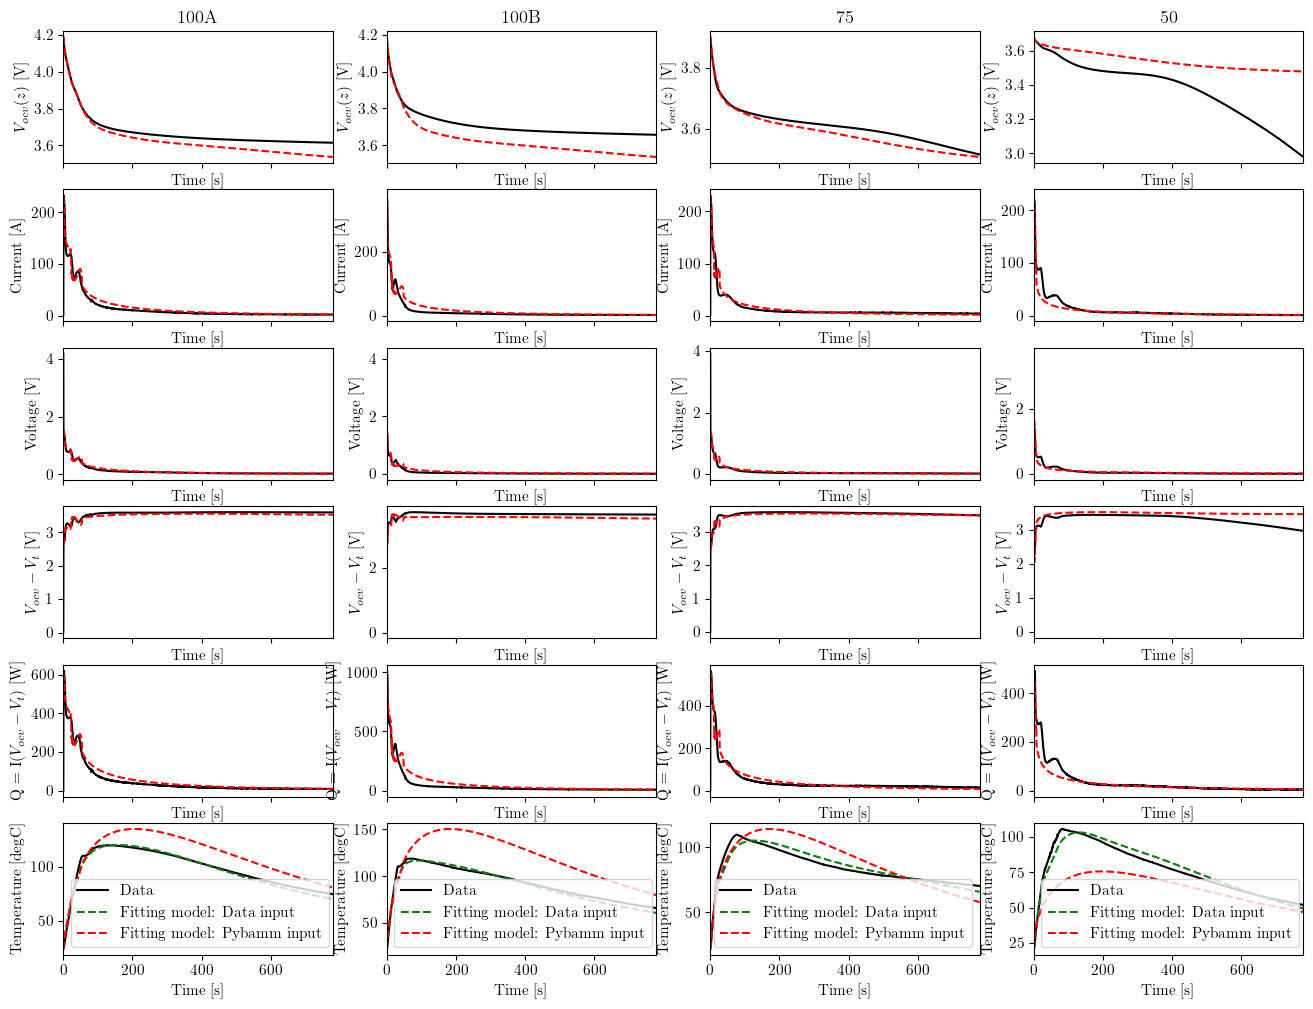

In [13]:
%matplotlib inline

# plot sim results
fig, ax= plt.subplots(6, len(SOC_names), figsize=(4*len(SOC_names), 12), sharex=True) #, constrained_layout=True
# ax = ax.flatten()

for j, (SOC_name,data,solution_pybamm_model) in enumerate(zip(SOC_names, datas, solutions_pybamm_model)):
    print(SOC_name)
    
    T_amb_0 = data.Temp[0]
    h = hs[SOC_name]
    Cp = Cps[SOC_name]
    SOC_0 = SOC_0s[SOC_name]
    t = solution_pybamm_model["Time [s]"].entries
    I = solution_pybamm_model['Current [A]'](t=t)#*4.6
    Vt = solution_pybamm_model["Terminal voltage [V]"](t=t)
    AhT_calculated = integrate.cumtrapz(abs(I), t)/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    SOC = SOC_0s[SOC_name] - AhT_calculated/Q_nom # load data import ESC data from file
    print('sim_pybamm_input')
    sim_pybamm_input = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I,(ocv(SOC)-Vt))#V_ocv-V with I and Vt from pybamm
    print('sim_data_input')
    sim_data_input = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, data.t, data.I,(ocv(data.SOC)-data.V))#V_ocv-V with I and Vt from data

    i = 0
    ax[i,j].plot(data.t, ocv(data.SOC), 'k',label = 'Data')
    ax[i,j].plot(t,ocv(SOC), '--r',label = 'Fitting model: Pybamm input')
    ax[i,j].set_ylabel("$V_{ocv}(z)$  [V]")
    ax[i,j].set_xlabel("Time [s]")

    i = 1
    ax[i,j].plot(data.t, data.I, 'k',label = 'Data')
    # ax[i,j].plot(data.t, sim_data_input.solution['Volume-averaged cell temperature [K]'].entries-273.15, '--g',label = 'Fitting model: Data input')
    ax[i,j].plot(t, I, '--r',label = 'Fitting model: Pybamm input')
    ax[i,j].set_ylabel("Current [A]")
    ax[i,j].set_xlabel("Time [s]")

    i = 2
    ax[i,j].plot(data.t, data.V, 'k',label = 'Data')
    # ax[i,j].plot(data.t, sim_data_input.solution['Volume-averaged cell temperature [K]'].entries-273.15, '--g',label = 'Fitting model: Data input')
    ax[i,j].plot(t, Vt, '--r',label = 'Fitting model: Pybamm input')
    ax[i,j].set_ylabel("Voltage [V]")
    ax[i,j].set_xlabel("Time [s]")

    i = 3
    ax[i,j].plot(data.t, ocv(data.SOC)-data.V, 'k',label = 'Data')
    # ax[i].plot(data.t, sim_data_input.solution['Volume-averaged cell temperature [K]'].entries-273.15, '--g',label = 'Fitting model: Data input')
    ax[i,j].plot(t, ocv(SOC)-Vt, '--r',label = 'Fitting model: Pybamm input')
    ax[i,j].set_ylabel("$V_{ocv} - V_t$ [V]")
    ax[i,j].set_xlabel("Time [s]")

    i = 4
    ax[i,j].plot(data.t, data.I*(ocv(data.SOC)-data.V), 'k',label = 'Data')
    ax[i,j].plot(t, I*(ocv(SOC)-Vt), '--r',label = 'Fitting model: Pybamm input')
    ax[i,j].set_ylabel("Q = I($V_{ocv} - V_t$) [W]")
    ax[i,j].set_xlabel("Time [s]")

    i = 5
    ax[i,j].plot(data.t, data.Temp, 'k',label = 'Data')
    ax[i,j].plot(data.t, sim_data_input.solution['Volume-averaged cell temperature [K]'].entries-273.15, '--g',label = 'Fitting model: Data input')
    ax[i,j].plot(data.t, sim_pybamm_input.solution['Volume-averaged cell temperature [K]'](data.t)-273.15, '--r',label = 'Fitting model: Pybamm input')
    ax[i,j].set_ylabel("Temperature [degC]")
    ax[i,j].set_xlabel("Time [s]")

    ax[-1,j].legend()
    ax[-1,j].set_xlim([0,data.t.iloc[-1]])
    ax[0,j].set_title(SOC_name)




# Run fitting model with I and V from SPMe 

In [ ]:
solutions_fitting_model = []

for i, SOC_name in enumerate(SOC_names): 
    print(SOC_name)
    T_amb_0 = datas[i].Temp[0]
    h = hs[SOC_name]
    Cp = Cps[SOC_name]
    SOC_0 = SOC_0s[SOC_name]
    t = solutions_pybamm_model[i]["Time [s]"].entries
    I = solutions_pybamm_model[i]['Current [A]'](t=t)#*4.6
    V = solutions_pybamm_model[i]['Terminal voltage [V]'](t=t)
    Q = solutions_pybamm_model[i]['Volume-averaged total heating'](t=t)
    V_ocv = solutions_pybamm_model[i]["X-averaged open circuit voltage [V]"].entries
    dV = solutions_pybamm_model[i]["Change in measured open circuit voltage [V]"].entries
    Vt = solutions_pybamm_model[i]["Terminal voltage [V]"](t=t)
    AhT_calculated = integrate.cumtrapz(abs(I), t)/3600
    AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
    SOC = SOC_0s[SOC_name] - AhT_calculated/Q_nom # load data import ESC data from file
    # Q_fit = I*(ocv(SOC) - Vt)

    # sim = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I,(ocv(SOC)-Vt))#V_ocv-V with ocv from data
    # solutions_fitting_model.append(sim.solution)
    sim = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, I,V_ocv-V-dV)#V_ocv-V with Up and Un from pybamm
    # sim = sim_thermal_fitting(h,Cp, SOC_0, T_amb_0, t, Q)
    solutions_fitting_model.append(sim.solution)

## Plot pybamm vs fitting model

In [ ]:
chemistry = pybamm.parameter_sets.Tran2023
param = pybamm.ParameterValues(chemistry)
T_amb_0 = datas[0].Temp[0]

param.update({
    "Ambient temperature [K]":T_amb_0 + 273.15,
    "Initial temperature [K]": T_amb_0 + 273.15,
    "Negative tab width [m]":2.5e-2,
    "Positive tab width [m]":2.5e-2,
    # "Edge heat transfer coefficient [W.m-2.K-1]":h,
    "Total heat transfer coefficient [W.m-2.K-1]":h,
    "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
    "Cell open circuit voltage [V]": ocv,
    "Cell capacity [A.h]": 4.6, #nominal
    "Typical current [A]": 4.6,
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
liion = pybamm.LithiumIonParameters()
Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)
C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
L_x = param.evaluate(pybamm.geometric_parameters.L_x)
L_xn = param.evaluate(pybamm.geometric_parameters.n.L)
L_y = param.evaluate(pybamm.geometric_parameters.L_y)
L_z = param.evaluate(pybamm.geometric_parameters.L_z)
L = param.evaluate(pybamm.geometric_parameters.L)
V_cell = L*L_y*L_z

2024-01-09 11:48:21.174 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:48:21.178 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:48:21.180 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:48:21.182 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:48:21.185 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:48:21.187 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:48:21.191 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:48:21.193 - [WARNING] processed_variable.__call__(459): Calling varia

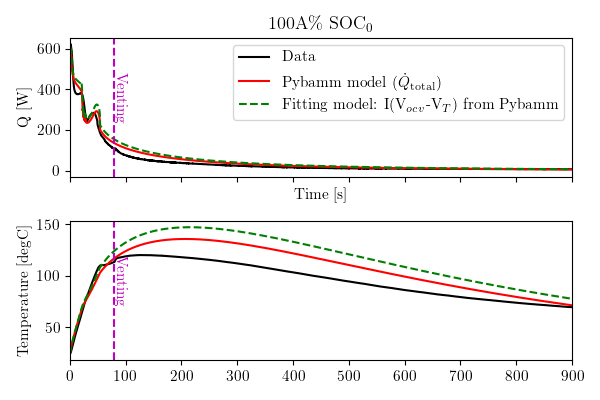

In [ ]:
%matplotlib widget
# plot 
fig, ax= plt.subplots(2, len(SOC_names), figsize=(6, 4), sharex=True) #, constrained_layout=True
ax = ax.flatten()
for i, (SOC_name, data, solution_pybamm, solution_fitting) in enumerate(zip(SOC_names, datas, solutions_pybamm_model, solutions_fitting_model)):

    dTdt_data = np.diff(data.Temp)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*16,3)
    t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]

    T_pybamm = solution_pybamm['Volume-averaged cell temperature [K]']
    Q_pybamm = solution_pybamm['Volume-averaged total heating']
    Q_tab_pybamm = solution_pybamm['Volume-averaged tab heating']

    dTdt_sim_pybamm = np.diff(T_pybamm(data.t[0:-1]))/np.diff(data.t[0:-1])
    RMSE_dT_pybamm = np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim_pybamm)))
    rmse_T_pybamm = np.sqrt(np.mean(np.square(data.Temp- (T_pybamm(data.t)-273.15))))

    T_fitting = solution_fitting['Volume-averaged cell temperature [K]']
    Q_fitting = solution_fitting['Volume-averaged total heating']
    dTdt_sim_fitting = np.diff(T_fitting(data.t[0:-1]))/np.diff(data.t[0:-1])
    RMSE_dT_fitting = np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim_fitting)))
    rmse_T_fitting = np.sqrt(np.mean(np.square(data.Temp- (T_fitting(data.t)-273.15))))

    # plot
    ax[0].plot(data.t, data.I*(ocv(data.SOC)-data.V), color = 'k', label = "Data")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    ax[0].plot(data.t, Q_pybamm(data.t)*Q_scale*V_cell, color = 'r', label = "Pybamm model ($\dot{Q}_{\mathrm{total}}$)")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    # ax.plot(data.t, Q_tab_pybamm(t= data.t)*Q_scale*V_cell, color = 'orange', label = "Pybamm Q$_{tab}$")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    ax[0].plot(data.t, Q_fitting(data.t)*Q_scale*V_cell, '--g', label = "Fitting model: I(V$_{ocv}$-V$_T$) from Pybamm")# (RMSE = " + str(np.round(rmse_T_fitting, 1)) + '$^\circ$C)')
    ax[0].set_xlabel("Time [s]")
    ax[0].set_ylabel("Q [W]")
    ax[0].set_xlim([0,t_end])
    ax[0].set_title(SOC_name + "\% SOC$_0$")
    ax[0].legend(loc = 'upper right')

    ax[1].plot(data.t, data.Temp, color = 'k', label = "Data")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    ax[1].plot(data.t, T_pybamm(data.t)-273.15, color = 'r', label = "Pybamm model")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    ax[1].plot(data.t, T_fitting(data.t)-273.15, '--g', label = "Fitting model: I(V$_{ocv}$-V$_T$) from Pybamm")# (RMSE = " + str(np.round(rmse_T_fitting, 1)) + '$^\circ$C)')
    ax[1].set_ylabel("Temperature [degC]")

for axs in fig.get_axes():
    if (SOC_0 ==1):
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
        ylims = axs.get_ylim()
        axs.plot([t_vent]*2, list(ylims), color = 'm', linestyle = '--')
        axs.annotate('Venting', xy=(t_vent, np.diff(ylims)*0.4+ ylims[0]), rotation=-90, color = 'm')
        axs.set_ylim(ylims) # keep original limits
            
plt.tight_layout()
# plt.savefig('./figs/' + SOC_name + 'ESC_thermal_comparison.eps', format='eps', dpi = 300)
plt.show()


2024-01-09 11:30:12.051 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:30:12.052 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:30:12.053 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:30:12.053 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:30:12.094 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:30:12.095 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:30:12.101 - [WARNING] processed_variable.__call__(459): Calling variable outside interpolation range (returns 'nan')
2024-01-09 11:30:12.103 - [WARNING] processed_variable.__call__(459): Calling varia

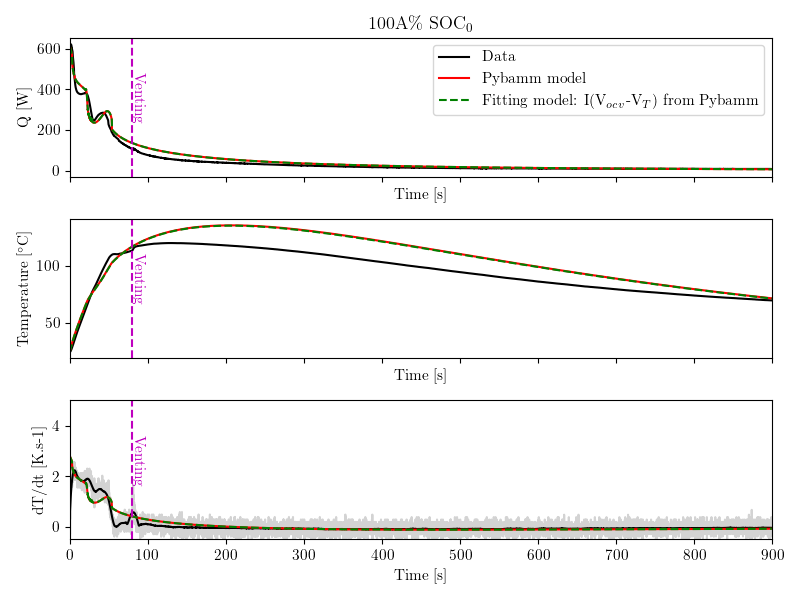

No such comm: 904114473f1f49ef836ac464d3ccec5e


In [ ]:
%matplotlib widget
# plot 
fig, ax= plt.subplots(3, len(SOC_names), figsize=(8, 6*len(SOC_names)), sharex=True) #, constrained_layout=True
ax = ax.flatten()

for i, (SOC_name, data, solution_pybamm, solution_fitting) in enumerate(zip(SOC_names, datas, solutions_pybamm_model, solutions_fitting_model)):

    dTdt_data = np.diff(data.Temp)/np.diff(data.t)
    dT_filtered = signal.savgol_filter(dTdt_data, 10*16,3)
    t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]

    T_pybamm = solution_pybamm['Volume-averaged cell temperature [K]']
    Q_pybamm = solution_pybamm['Volume-averaged total heating']
    Q_tab_pybamm = solution_pybamm['Volume-averaged tab heating']

    dTdt_sim_pybamm = np.diff(T_pybamm(data.t[0:-1]))/np.diff(data.t[0:-1])
    RMSE_dT_pybamm = np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim_pybamm)))
    rmse_T_pybamm = np.sqrt(np.mean(np.square(data.Temp- (T_pybamm(data.t)-273.15))))

    T_fitting = solution_fitting['Volume-averaged cell temperature [K]']
    Q_fitting = solution_fitting['Volume-averaged total heating']
    dTdt_sim_fitting = np.diff(T_fitting(data.t[0:-1]))/np.diff(data.t[0:-1])
    RMSE_dT_fitting = np.sqrt(np.mean(np.square(dT_filtered[0:-1] - dTdt_sim_fitting)))
    rmse_T_fitting = np.sqrt(np.mean(np.square(data.Temp- (T_fitting(data.t)-273.15))))

    # plot
    chemistry = pybamm.parameter_sets.Tran2023
    param = pybamm.ParameterValues(chemistry)
    T_amb_0 = datas[0].Temp[0]

    param.update({
        "Ambient temperature [K]":T_amb_0 + 273.15,
        "Initial temperature [K]": T_amb_0 + 273.15,
        "Negative tab width [m]":2.5e-2,
        "Positive tab width [m]":2.5e-2,
        # "Edge heat transfer coefficient [W.m-2.K-1]":h,
        "Total heat transfer coefficient [W.m-2.K-1]":h,
        "Negative electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Positive electrode specific heat capacity [J.kg-1.K-1]": 1100*Cp,
        "Cell open circuit voltage [V]": ocv,
        "Cell capacity [A.h]": 4.6, #nominal
        "Typical current [A]": 4.6,
        "Negative electrode thickness [m]":62E-06*4.2/5,
        "Positive electrode thickness [m]":67E-06*4.2/5,
    }, check_already_exists = False)
    liion = pybamm.LithiumIonParameters()
    Q_scale = param.evaluate(liion.i_typ) * param.evaluate(liion.potential_scale) / param.evaluate(liion.L_x)
    C_th = param.evaluate(liion.tau_th_yz)/param.evaluate(liion.tau_discharge) # self.tau_th_yz / self.timescale
    L_x = param.evaluate(pybamm.geometric_parameters.L_x)
    L_xn = param.evaluate(pybamm.geometric_parameters.n.L)
    L_y = param.evaluate(pybamm.geometric_parameters.L_y)
    L_z = param.evaluate(pybamm.geometric_parameters.L_z)
    L = param.evaluate(pybamm.geometric_parameters.L)
    V_cell = L*L_y*L_z

    ax[0].plot(data.t, data.I*(ocv(data.SOC)-data.V), color = 'k', label = "Data")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    ax[0].plot(data.t, Q_pybamm(data.t)*Q_scale*V_cell, color = 'r', label = "Pybamm model")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    # ax[0].plot(data.t, Q_tab_pybamm(t= data.t)*Q_scale*V_cell, color = 'orange', label = "Pybamm Q$_{tab}$")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    ax[0].plot(data.t, Q_fitting(data.t)*Q_scale*V_cell, '--g', label = "Fitting model: I(V$_{ocv}$-V$_T$) from Pybamm")# (RMSE = " + str(np.round(rmse_T_fitting, 1)) + '$^\circ$C)')
    ax[0].set_xlabel("Time [s]")
    ax[0].set_ylabel("Q [W]")
    ax[0].set_xlim([0,t_end])
    ax[0].set_title(SOC_name + "\% SOC$_0$")
    ax[0].legend(loc = 'upper right')

    ax[1].plot(data.t, data.Temp, color = 'k', label = "Data")
    ax[1].plot(data.t, T_pybamm(data.t)-273.15, color = 'r', label = "Pybamm model")# (RMSE = " + str(np.round(rmse_T_pybamm, 1)) + '$^\circ$C)')
    ax[1].plot(data.t, T_fitting(data.t)-273.15, '--g', label = "Fitting model: I(V$_{ocv}$-V$_T$) from Pybamm")# (RMSE = " + str(np.round(rmse_T_fitting, 1)) + '$^\circ$C)')
    ax[1].set_xlabel("Time [s]")
    ax[1].set_ylabel("Temperature [$^\circ$C]")
    ax[1].set_xlim([0,t_end])
    # ax[1].set_ylim([20,135])
    # ax[1].legend(loc = 'upper right')

    ax[2].plot(data.t[0:-1], dTdt_data, color = 'lightgrey', label = "Data: Calculated")
    ax[2].plot(data.t[0:-1], dT_filtered, color = 'k', label = "Data: S-G filtered")
    ax[2].plot(data.t[0:-2], dTdt_sim_pybamm, color = 'r', label = "Pybamm model")# (RMSE = " + str(round(RMSE_dT_pybamm, 2)) + " K.s-1)")
    ax[2].plot(data.t[0:-2], dTdt_sim_fitting, '--g', label = "Fitting model: I(V$_{ocv}$-V$_T$) from Pybamm")# (RMSE = " + str(round(RMSE_dT_fitting, 2)) + " K.s-1)")
    ax[2].set_ylabel("dT/dt [K.s-1]")
    ax[2].set_xlabel("Time [s]")
    ax[2].set_ylim([-0.5, 5])
    ax[2].set_xlim([0,t_end])



for axs in fig.get_axes():
    if (SOC_0 ==1):
        t_vent = data.t.iloc[0:-1][abs(np.diff(data['F'])) > 100].iloc[0]
        T_vent = data.Temp[abs(data.t-t_vent)<0.2].iloc[0]
        ylims = axs.get_ylim()
        axs.plot([t_vent]*2, list(ylims), color = 'm', linestyle = '--')
        axs.annotate('Venting', xy=(t_vent, np.diff(ylims)*0.4+ ylims[0]), rotation=-90, color = 'm')
        axs.set_ylim(ylims) # keep original limits
            
plt.tight_layout()
# plt.savefig('./figs/' + SOC_name + 'ESC_thermal_comparison.eps', format='eps', dpi = 300)
plt.show()


In [ ]:
model = pybamm.lithium_ion.SPMe()
model.variables.search('voltage')


Battery voltage [V]
Change in measured open circuit voltage
Change in measured open circuit voltage [V]
Local voltage
Local voltage [V]
Measured battery open circuit voltage [V]
Measured open circuit voltage
Measured open circuit voltage [V]
Terminal voltage
Terminal voltage [V]
X-averaged battery open circuit voltage [V]
X-averaged open circuit voltage
X-averaged open circuit voltage [V]


In [ ]:
%matplotlib inline
solution = solutions_pybamm_model[0]
quick_plot = pybamm.QuickPlot(solution, figsize=[7,4],n_rows = 1, output_variables=[ 
    "Current [A]",
    ["Terminal voltage [V]", 
    # "Electrolyte potential [V]",
    # "Electrolyte current density",
    # "Volume-averaged tab heating", 
    # "Irreversible electrochemical heating",
    # "Ohmic heating", 
    "Battery voltage [V]",
    "Measured open circuit voltage [V]",
    # "Local voltage [V]"
],
    "Negative electrode reaction overpotential",
    ])
quick_plot.dynamic_plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=899.9000000000001, step=8.999), Output()), _…

## Plot OCVs using surface and average concentrations

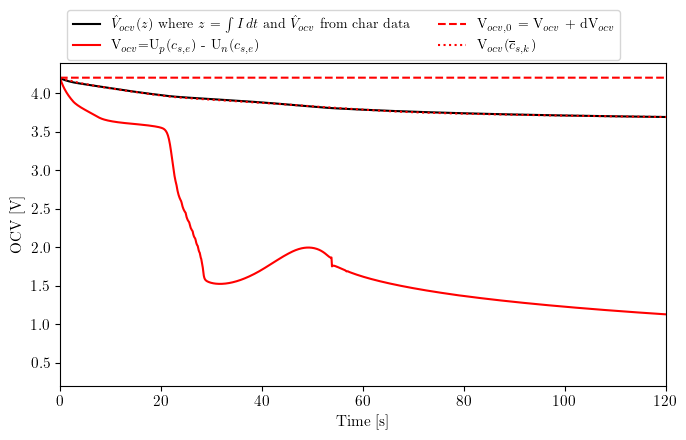

No such comm: ad5cf688a34d4031b3c7d1cb4576da69


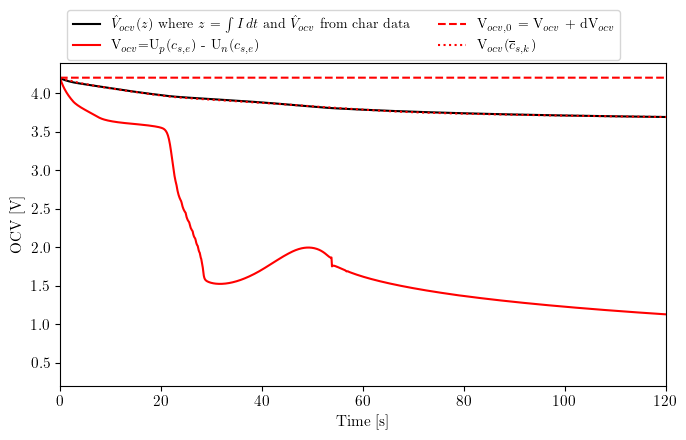

In [ ]:
I = solution['Current [A]'].entries
AhT_calculated = integrate.cumtrapz(abs(I), t)/3600
AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
SOC = SOC_0s[SOC_name] - AhT_calculated/Q_nom # load data import ESC data from file
Vt = solution['Terminal voltage [V]'].entries
V_ocv = solution["X-averaged open circuit voltage [V]"].entries
dOCV = -solution["Change in measured open circuit voltage [V]"].entries

#calculate ocv based on avg particle concentration
Un = param['Negative electrode OCP [V]']
c_n_avg = solution['Average negative particle concentration'].entries
Up = param['Positive electrode OCP [V]']
c_p_avg = solution['Average positive particle concentration'].entries
V_ocv_avg = [Up(cp).evaluate()-Un(cn).evaluate() for (cn, cp) in zip(c_n_avg, c_p_avg)]

# "Measured open circuit voltage [V]": ocv_dim,

fig, ax = plt.subplots(1,  1, figsize=(7, 4), sharex=True, constrained_layout=True)#, constrained_layout=True
sim_colors = ['r', 'b', 'limegreen','darkorange']
# ax.plot(data.t, data.I*(ocv(data.SOC) - data.V), color = 'k', linestyle = '-', label = 'Data $\dot{Q}$') #$_\mathrm{{total}}$
ax.plot(t, ocv(SOC), color = 'k', linestyle = '-', label = ' $\hat{V}_{ocv}(z)$ where $z$ = $\int I\,dt$ and $\hat{V}_{ocv}$ from char data') #$_\mathrm{{total}}$
ax.plot(t, V_ocv, color = 'r', linestyle = '-', label = ' V$_{ocv}$=U$_p(c_{s,e})$ - U$_n(c_{s,e})$') #$_\mathrm{{total}}$
ax.plot(t, V_ocv + dOCV, color = 'r', linestyle = '--', label = ' V$_{ocv,0}$ = V$_{ocv}$ + dV$_{ocv}$') #$_\mathrm{{total}}$
ax.plot(t, V_ocv_avg, color = 'r', linestyle = ':', label = ' V$_{ocv}(\overline{c}_{s,k})$') #$_\mathrm{{total}}$

ax.set_xlim(0,120)
ax.set_ylabel('OCV [V]')
ax.set_xlabel('Time [s]')
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, .95))
# plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

## Plot heat gen to see difference in pybamms

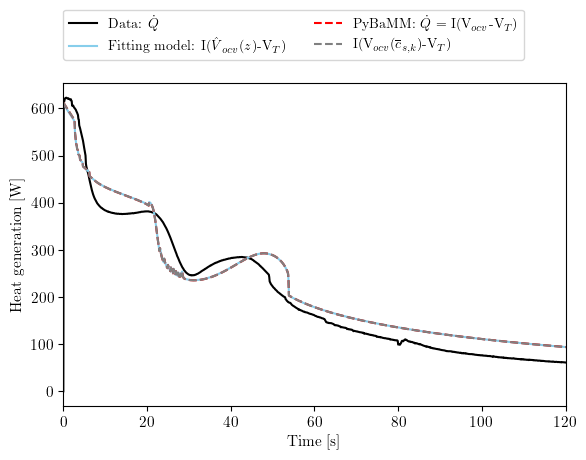

In [ ]:
%matplotlib inline

# get geometric parameters
param = pybamm.ParameterValues('Tran2023')
param.update({
    "Negative electrode thickness [m]":62E-06*4.2/5,
    "Positive electrode thickness [m]":67E-06*4.2/5,
}, check_already_exists = False)
solution = solutions_pybamm_model[0]
R_tab = R_tabs['100A']
L_x = param.evaluate(pybamm.geometric_parameters.L_x)
L_xn = param.evaluate(pybamm.geometric_parameters.n.L)
L_y = param.evaluate(pybamm.geometric_parameters.L_y)
L_z = param.evaluate(pybamm.geometric_parameters.L_z)
L = param.evaluate(pybamm.geometric_parameters.L)
Vx = L_x*L_y*L_z
V = L*L_y*L_z

# calculate SOC, Vocv, and other voltages 
I = solution['Current [A]'].entries
AhT_calculated = integrate.cumtrapz(abs(I), t)/3600
AhT_calculated = np.append(AhT_calculated,AhT_calculated[-1])
SOC = SOC_0s[SOC_name] - AhT_calculated/Q_nom # load data import ESC data from file

#calculate ocv based on avg particle concentration
Un = param['Negative electrode OCP [V]']
c_n_avg = solution['Average negative particle concentration'].entries
Up = param['Positive electrode OCP [V]']
c_p_avg = solution['Average positive particle concentration'].entries
# V_ocv_avg = [Up(cp).evaluate()-Un(cn).evaluate() for (cn, cp) in zip(c_n_avg, c_p_avg)]
Vt = solution['Terminal voltage [V]'].entries
V_ocv = solution["X-averaged open circuit voltage [V]"].entries
# "Measured open circuit voltage [V]": ocv_dim,

# Q_tabbing = I**2*R_tab
Q_total = (solution['Volume-averaged total heating [W.m-3]'].entries)*V
Q_sei = solution['SEI decomposition heating [W.m-3]'].entries*L_xn*L_y*L_z # should be anode not cell volume?
Q_rxn = (solution['Volume-averaged irreversible electrochemical heating [W.m-3]'].entries)*V
Q_tabbing = solution['Tab heating [W.m-3]'].entries*V #Vx
Q_ohm = solution['Volume-averaged Ohmic heating [W.m-3]'].entries*V #- Q_tabbing  
dOCV = solution["Change in measured open circuit voltage [V]"].entries
t = solution['Time [s]'].entries
xlabel = "Time [s]"

fig, ax = plt.subplots(1,  1, figsize=(6, 4), sharex=True, constrained_layout=True)#, constrained_layout=True
sim_colors = ['r', 'b', 'limegreen','darkorange']
ax.plot(data.t, data.I*(ocv(data.SOC) - data.V), color = 'k', linestyle = '-', label = 'Data: $\dot{Q}$') #$_\mathrm{{total}}$
ax.plot(t, I*(ocv(SOC) - Vt), color = 'skyblue', linestyle = '-', label = 'Fitting model: I($\hat{V}$$_{ocv}(z)$-V$_T$)') #$_\mathrm{{total}}$
# ax.plot(t, I*(V_ocv - Vt), color = 'g', linestyle = '-', label = 'PyBaMM: I(V$_{ocv}$-V$_T$)') #$_\mathrm{{total}}$
ax.plot(t, Q_total, color = 'r', linestyle = '--', label = 'PyBaMM: $\dot{Q}$ = I(V$_{ocv}$-V$_T$)') #$_\mathrm{{total}}$
ax.plot(t, I*(V_ocv_avg- Vt), color = 'grey', linestyle = '--', label = ' I(V$_{ocv}(\overline{c}_{s,k})$-V$_T$)') #$_\mathrm{{total}}$

# ax.plot(t, Q_ohm + Q_tabbing + Q_rxn + Q_sei, color = 'cyan', linestyle = ':', label = 'Validate Q$_\mathrm{{total}}$')
# ax.plot(t, Q_ohm, color = 'm', linestyle = '--', label = '$\dot{Q}_\mathrm{{ohm}}$')
# ax.plot(t, Q_tabbing, color = sim_colors[1], linestyle = ':', label = '$\dot{Q}_\mathrm{{tab}}$')
# ax.plot(t, Q_rxn, color = sim_colors[2], linestyle = '-.', label = '$\dot{Q}_\mathrm{{rxn}}$')
# ax.plot(t, Q_sei, color = sim_colors[3], linestyle = '--', label = '$\dot{Q}_\mathrm{{SEI}}$')

ax.set_xlim(0,120)
ax.set_xlabel(xlabel)
ax.set_ylabel('Heat generation [W]')
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, prop={'size': 10},  bbox_to_anchor=(0.5, 1.0))
# plt.legend(loc = 'upper right')
plt.tight_layout()
plt.show()

In [ ]:
# sanity check R_tab heat gen
print(data.I[1]**2*R_tabs['100A'])
print(Q_tabbing[0])

463.70356009147133
459.4044968429812


# Plot voltage losses

AttributeError: PolyCollection.set() got an unexpected keyword argument 'split_by_electrode'

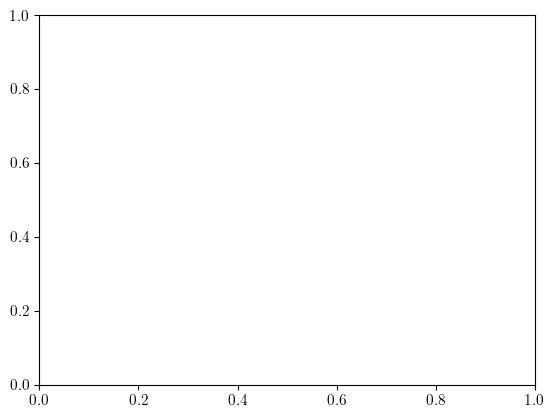

In [ ]:
fig,ax = pybamm.plot_voltage_components(solutions_pybamm_model[0], testing=True, split_by_electrode=True) #, split_by_electrode=True
leg = ax.legend(loc="upper right", frameon=True)
leg.get_frame().set_edgecolor("k")
